In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"
V1_PATH = os.path.join(
    DATASET_PATH,
    "processed_dataset_v1"
)

print("Dataset V1 path:")
print(V1_PATH)

Dataset V1 path:
/content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1


In [ ]:
data = np.load(
    os.path.join(V1_PATH, "sequences_v1.npz"),
    allow_pickle=True
)

X_sequences = data["X"]
y_soh = data["SoH"]
y_rul = data["RUL"]

sequence_battery_ids = data["battery_id"]
sequence_splits = data["split"]

print("Dataset V1 loaded successfully.")
print()
print("X shape:", X_sequences.shape)
print("SoH shape:", y_soh.shape)
print("RUL shape:", y_rul.shape)
print("Battery ID shape:", sequence_battery_ids.shape)
print("Split shape:", sequence_splits.shape)

Dataset V1 loaded successfully.

X shape: (2287, 10, 2)
SoH shape: (2287,)
RUL shape: (2287,)
Battery ID shape: (2287,)
Split shape: (2287,)


In [ ]:
print("Sequence split distribution:")
print(
    pd.Series(sequence_splits).value_counts()
)

Sequence split distribution:
train         1516
test           392
validation     379
Name: count, dtype: int64


In [ ]:
train_mask = sequence_splits == "train"
val_mask = sequence_splits == "validation"
test_mask = sequence_splits == "test"

X_train = X_sequences[train_mask]
X_val = X_sequences[val_mask]
X_test = X_sequences[test_mask]

y_soh_train = y_soh[train_mask]
y_soh_val = y_soh[val_mask]
y_soh_test = y_soh[test_mask]

y_rul_train = y_rul[train_mask]
y_rul_val = y_rul[val_mask]
y_rul_test = y_rul[test_mask]

print("Train:")
print("X:", X_train.shape)
print("SoH:", y_soh_train.shape)
print("RUL:", y_rul_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("SoH:", y_soh_val.shape)
print("RUL:", y_rul_val.shape)

print("\nTest:")
print("X:", X_test.shape)
print("SoH:", y_soh_test.shape)
print("RUL:", y_rul_test.shape)

Train:
X: (1516, 10, 2)
SoH: (1516,)
RUL: (1516,)

Validation:
X: (379, 10, 2)
SoH: (379,)
RUL: (379,)

Test:
X: (392, 10, 2)
SoH: (392,)
RUL: (392,)


In [ ]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.column_stack([
        y_soh_train,
        y_rul_train
    ]),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    np.column_stack([
        y_soh_val,
        y_rul_val
    ]),
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    np.column_stack([
        y_soh_test,
        y_rul_test
    ]),
    dtype=torch.float32
)

print("Tensor conversion completed.")

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

Tensor conversion completed.
X_train: torch.Size([1516, 10, 2])
y_train: torch.Size([1516, 2])


In [ ]:
BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")
print("Batch size:", BATCH_SIZE)

DataLoaders created.
Batch size: 32


In [ ]:
# Day 15 - Cell 10
# LSTM Model Architecture

class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=2,
        hidden_size=64,
        num_layers=2,
        output_size=2,
        dropout=0.2
    ):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        # LSTM output for every time step
        out, (hidden, cell) = self.lstm(x)

        # Take the final time step
        out = out[:, -1, :]

        # Fully connected output layer
        out = self.fc(out)

        return out


model = LSTMModel().to(device)

print(model)

LSTMModel(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
# Day 15 - Cell 11
# Loss function and optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Day 15 - Cell 12
# Train the LSTM model

NUM_EPOCHS = 100

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = (
        running_val_loss / len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] "
            f"Train Loss: {epoch_train_loss:.6f} "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

print("\nTraining completed.")

Epoch [  1/100] Train Loss: 3178.552438 Val Loss: 2176.239935
Epoch [ 10/100] Train Loss: 1454.470815 Val Loss: 921.313798
Epoch [ 20/100] Train Loss: 805.602999 Val Loss: 435.147294
Epoch [ 30/100] Train Loss: 622.082921 Val Loss: 343.471560
Epoch [ 40/100] Train Loss: 590.052262 Val Loss: 350.664780
Epoch [ 50/100] Train Loss: 587.229925 Val Loss: 360.521797
Epoch [ 60/100] Train Loss: 587.194416 Val Loss: 361.645453
Epoch [ 70/100] Train Loss: 587.039721 Val Loss: 361.915547
Epoch [ 80/100] Train Loss: 587.163615 Val Loss: 361.726728
Epoch [ 90/100] Train Loss: 587.092875 Val Loss: 362.052790
Epoch [100/100] Train Loss: 587.090467 Val Loss: 361.875259

Training completed.


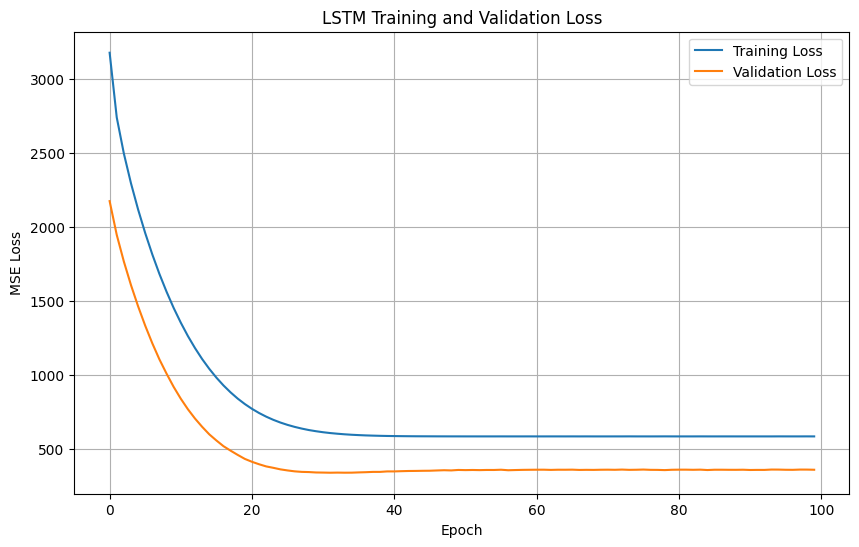

In [ ]:
# Day 15 - Cell 13
# Training and validation loss curves

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Day 15 - Cell 14
# Find the best validation epoch

best_epoch = np.argmin(val_losses) + 1
best_val_loss = val_losses[best_epoch - 1]

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)

Best Epoch: 32
Best Validation Loss: 341.8085914954032


In [ ]:
NUM_EPOCHS = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

CHECKPOINT_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1/lstm_best_model.pth"

for epoch in range(NUM_EPOCHS):

    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = (
        running_val_loss / len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] "
            f"Train Loss: {epoch_train_loss:.6f} "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

print("\nTraining completed.")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Checkpoint saved to:")
print(CHECKPOINT_PATH)

Epoch [  1/100] Train Loss: 587.110337 Val Loss: 361.417157
Epoch [ 10/100] Train Loss: 587.462792 Val Loss: 364.396814
Epoch [ 20/100] Train Loss: 513.863791 Val Loss: 311.650296
Epoch [ 30/100] Train Loss: 457.622282 Val Loss: 391.249566
Epoch [ 40/100] Train Loss: 442.590889 Val Loss: 338.239978
Epoch [ 50/100] Train Loss: 425.160510 Val Loss: 304.751950
Epoch [ 60/100] Train Loss: 419.951846 Val Loss: 309.225704
Epoch [ 70/100] Train Loss: 414.975077 Val Loss: 301.191721
Epoch [ 80/100] Train Loss: 414.193425 Val Loss: 301.061751
Epoch [ 90/100] Train Loss: 411.420732 Val Loss: 298.071909
Epoch [100/100] Train Loss: 405.527251 Val Loss: 296.781968

Training completed.
Best Epoch: 92
Best Validation Loss: 296.10531406855523
Checkpoint saved to:
/content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1/lstm_best_model.pth


In [ ]:
# Day 15 - Cell 17
# Generate predictions on the test set

all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        all_predictions.append(
            predictions.cpu().numpy()
        )

        all_targets.append(
            y_batch.numpy()
        )

y_pred = np.concatenate(all_predictions, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print("Prediction completed.")
print("Actual shape:", y_true.shape)
print("Predicted shape:", y_pred.shape)

Prediction completed.
Actual shape: (392, 2)
Predicted shape: (392, 2)


In [ ]:
# Day 15 - Cell 18
# Separate SoH and RUL

soh_true = y_true[:, 0]
soh_pred = y_pred[:, 0]

rul_true = y_true[:, 1]
rul_pred = y_pred[:, 1]

print("SoH samples:", len(soh_true))
print("RUL samples:", len(rul_true))

print("\nFirst 5 SoH predictions:")
print(soh_pred[:5])

print("\nFirst 5 RUL predictions:")
print(rul_pred[:5])

SoH samples: 392
RUL samples: 392

First 5 SoH predictions:
[62.960827 60.645798 58.206604 56.30233  54.91336 ]

First 5 RUL predictions:
[1.6681544  1.292034   0.9568365  0.80267304 0.759595  ]


In [ ]:
# Day 15 - Cell 19
# Evaluate LSTM using agreed metrics

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true, y_pred
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2


soh_mae, soh_rmse, soh_mape, soh_r2 = calculate_metrics(
    soh_true,
    soh_pred
)

rul_mae, rul_rmse, rul_mape, rul_r2 = calculate_metrics(
    rul_true,
    rul_pred
)


results = pd.DataFrame({
    "Target": ["SoH", "RUL"],
    "MAE": [soh_mae, rul_mae],
    "RMSE": [soh_rmse, rul_rmse],
    "MAPE (%)": [soh_mape, rul_mape],
    "R2": [soh_r2, rul_r2]
})

print(results.to_string(index=False))

Target       MAE      RMSE     MAPE (%)         R2
   SoH 21.812994 24.003999 3.419729e+17  -1.415210
   RUL  2.161099  5.490886 9.388537e+17 -57.889362


In [22]:
import time

# Make sure the best model is in evaluation mode
model.eval()

# Count parameters
lstm_parameters = sum(
    p.numel()
    for p in model.parameters()
)

# Warm-up inference
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        _ = model(X_batch)
        break

# Measure inference time on complete test set
start_time = time.time()

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        _ = model(X_batch)

lstm_inference_time = time.time() - start_time

print("LSTM Model Complexity")
print("=" * 40)
print("Total Parameters:", lstm_parameters)
print("Inference Time:", f"{lstm_inference_time:.4f} seconds")
print("Test Samples:", len(test_loader.dataset))

LSTM Model Complexity
Total Parameters: 50818
Inference Time: 0.0183 seconds
Test Samples: 392
